In [84]:
import os
import pandas as pd
import tensorflow as tf
from pathlib import Path
import numpy as np

In [85]:
print(Path.cwd().parent)

c:\Users\prach\OneDrive - Swinburne University\University\2026_sem1\cos30082\assignment\AMLFacialRecognitionProject


In [86]:
PROJECT_ROOT =  Path.cwd().parent

DATASET = (
    PROJECT_ROOT
    / "data"
    / "lcc-fasd-casia"
    / "LCC_FASD"
)

TRAIN_IMG_DIR = DATASET / "LCC_FASD_training"
VAL_IMG_DIR = DATASET / "LCC_FASD_development"
TEST_IMG_DIR = DATASET / "LCC_FASD_evaluation"

In [87]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

In [88]:
def count_images(folder):
    folder = Path(folder)
    print(folder.name)
    for cls in ["real", "spoof"]:
        files = list((folder / cls).glob("*"))
        print(cls, len(files))

count_images(TRAIN_IMG_DIR)
count_images(VAL_IMG_DIR)
count_images(TEST_IMG_DIR)

LCC_FASD_training
real 1302
spoof 7444
LCC_FASD_development
real 416
spoof 2590
LCC_FASD_evaluation
real 323
spoof 7312


In [89]:
def make_balanced_dataset(directory, seed=42):
    real_imgs  = list((directory / "real").glob("*"))
    spoof_imgs = list((directory / "spoof").glob("*"))

    random.seed(seed)
    n = min(len(real_imgs), len(spoof_imgs))
    real_imgs  = random.sample(real_imgs,  n)
    spoof_imgs = random.sample(spoof_imgs, n)

    all_imgs = [(str(p), 0) for p in real_imgs] + [(str(p), 1) for p in spoof_imgs]
    random.shuffle(all_imgs)

    paths  = [p for p, label in all_imgs]
    labels = [label for p, label in all_imgs]

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        return img, tf.cast(label, tf.float32)

    return ds.map(load, num_parallel_calls=AUTOTUNE)

In [90]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

def augment(image, label):
    image = data_augmentation(image, training=True)
    return image, label

In [91]:
train_ds = make_balanced_dataset(TRAIN_IMG_DIR)
valid_ds = make_balanced_dataset(VAL_IMG_DIR)
test_ds  = make_balanced_dataset(TEST_IMG_DIR)

train = train_ds.map(augment, num_parallel_calls=AUTOTUNE).shuffle(1000, seed=42).batch(BATCH_SIZE).prefetch(AUTOTUNE)
valid = valid_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
test  = test_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)

# count balanced sizes
train_labels = [int(label) for _, label in make_balanced_dataset(TRAIN_IMG_DIR)]
print("train size:", len(train_labels))
print("real:", train_labels.count(0), "spoof:", train_labels.count(1))

train size: 2604
real: 1302 spoof: 1302


In [92]:
def depthwise_sep_block(x, filters, stride=1):
    residual = x

    x = tf.keras.layers.DepthwiseConv2D(kernel_size=3, strides=stride, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(filters, kernel_size=1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    if residual.shape[-1] != filters or stride != 1:
        residual = tf.keras.layers.Conv2D(filters, kernel_size=1, strides=stride, padding="same", use_bias=False)(residual)
        residual = tf.keras.layers.BatchNormalization()(residual)

    x = tf.keras.layers.Add()([x, residual])
    return x


def build_model(input_shape=(224, 224, 3)):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Rescaling(1.0 / 255)(inputs)

    x = tf.keras.layers.Conv2D(32, kernel_size=3, strides=2, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = depthwise_sep_block(x, filters=64,  stride=2)
    x = depthwise_sep_block(x, filters=128, stride=2)
    x = depthwise_sep_block(x, filters=128, stride=1)
    x = depthwise_sep_block(x, filters=256, stride=2)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    return tf.keras.Model(inputs, outputs, name="antispoof_custom")


antispoof_model_v3 = build_model()
antispoof_model_v3.summary()

Model: "antispoof_custom"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ input_layer_8[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 112, 112,  │        864 │ rescaling_3[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_30 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_12 │ (None, 56, 56,    │        288 │ re_lu_30[0][0]    │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_31 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 56, 56,    │      2,048 │ re_lu_31[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 56, 56,    │      2,048 │ re_lu_30[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_32 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 56, 56,    │          0 │ re_lu_32[0][0],   │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_13 │ (None, 28, 28,    │        576 │ add_12[0][0]      │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_33 (ReLU)     │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 145,473 (568.25 KB)

 Trainable params: 142,401 (556.25 KB)

 Non-trainable params: 3,072 (12.00 KB)

In [94]:
antispoof_model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [95]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    patience=8,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="./models/antispoof_custom.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

history = antispoof_model_v3.fit(
    train,
    validation_data=valid,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.6246 - auc: 0.6727 - loss: 0.8665 - precision: 0.6080 - recall: 0.5698
Epoch 1: val_auc improved from None to 0.73888, saving model to ./models/antispoof_custom.keras

Epoch 1: finished saving model to ./models/antispoof_custom.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 275ms/step - accuracy: 0.6563 - auc: 0.7161 - loss: 0.8286 - precision: 0.6717 - recall: 0.6114 - val_accuracy: 0.5000 - val_auc: 0.7389 - val_loss: 0.8647 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.7168 - auc: 0.7818 - loss: 0.7549 - precision: 0.7133 - recall: 0.7041
Epoch 2: val_auc did not improve from 0.73888
82/82 ━━━━━━━━━━━━━━━━━━━━ 22s 249ms/step - accuracy: 0.7189 - auc: 0.7875 - loss: 0.7486 - precision: 0.7258 - recall: 0.7035 - val_accuracy: 0.5000 - val_auc: 0.7362 - val_loss: 0.9760 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 

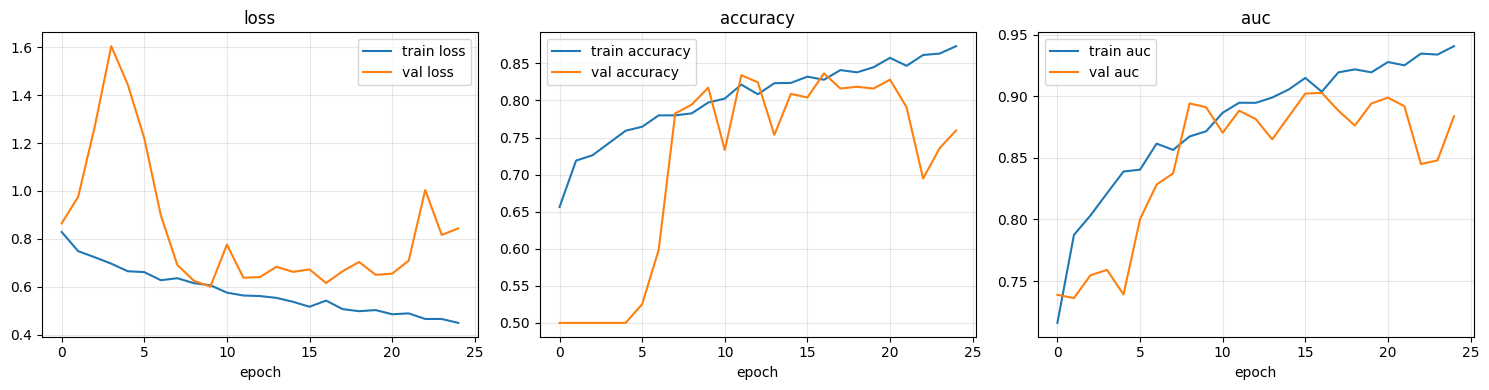

In [96]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["loss", "accuracy", "auc"]):
    ax.plot(history.history[metric], label=f"train {metric}")
    ax.plot(history.history[f"val_{metric}"], label=f"val {metric}")
    ax.set_title(metric)
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best threshold: 0.49  (F1: 0.8467)


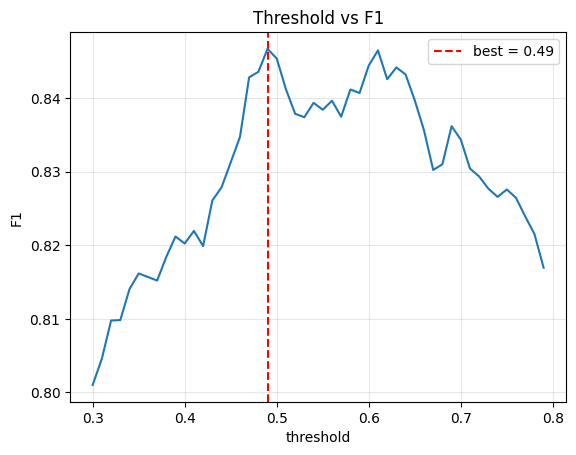

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

y_true = []
y_pred_raw = []

for images, labels in test:
    pred = antispoof_model_v3.predict(images, verbose=0)
    y_true.extend(labels.numpy().astype(int).flatten())
    y_pred_raw.extend(pred.flatten())

y_true     = np.array(y_true)
y_pred_raw = np.array(y_pred_raw)

thresholds = np.arange(0.3, 0.8, 0.01)
f1_scores = [f1_score(y_true, (y_pred_raw >= t).astype(int)) for t in thresholds]

BEST_THRESHOLD = thresholds[np.argmax(f1_scores)]
print(f"best threshold: {BEST_THRESHOLD:.2f}  (F1: {max(f1_scores):.4f})")

plt.plot(thresholds, f1_scores)
plt.axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"best = {BEST_THRESHOLD:.2f}")
plt.xlabel("threshold")
plt.ylabel("F1")
plt.title("Threshold vs F1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [98]:
y_pred = (y_pred_raw >= BEST_THRESHOLD).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["real", "spoof"]))

[[236  87]
 [ 22 301]]
              precision    recall  f1-score   support

        real       0.91      0.73      0.81       323
       spoof       0.78      0.93      0.85       323

    accuracy                           0.83       646
   macro avg       0.85      0.83      0.83       646
weighted avg       0.85      0.83      0.83       646



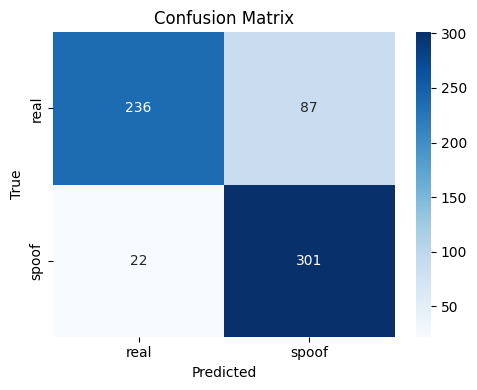

In [99]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["real", "spoof"], yticklabels=["real", "spoof"])
plt.ylabel("True")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [100]:
import json

os.makedirs('./models', exist_ok=True)

config = {"threshold": float(BEST_THRESHOLD), "img_size": list(IMG_SIZE)}
with open("./models/antispoof_custom_config.json", "w") as f:
    json.dump(config, f, indent=2)

antispoof_model_v3.save('./models/antispoof_custom.keras')
print("model saved")
print("threshold:", BEST_THRESHOLD)

model saved
threshold: 0.49000000000000016
